# 02 — Unperturbed GD-1 Mock Stream

This notebook constructs the **unperturbed control stream $S_0$** for the
stellar-stream perturbation experiment.

The stream is modeled as an extended tidally stripped population, not as a single
orbit. For the production model we use the **Chen et al. (2024) stream
distribution function (`ChenStreamDF`) and Gala's `MockStreamGenerator`**, with
a finite Plummer progenitor potential and a fixed Milky-Way background potential.

$$
\boxed{
\text{observed 6-D anchor}
\;\longrightarrow\;
\text{progenitor orbit}
\;\longrightarrow\;
\text{Chen+24 escape DF}
\;\longrightarrow\;
\text{self-gravitating progenitor}
\;\longrightarrow\;
S_0
}
$$

No dark-matter subhalo, GMC, globular cluster, bar, spiral structure, or other
perturbation is present in $S_0$.

## 1. Purpose and physical objective

The goal is to construct a physically motivated baseline against which all later perturbation experiments will be measured.

We do **not** force the smooth model to reproduce every observed GD-1 feature. The baseline must instead provide a dynamically coherent, reproducible control stream so that later differences
\[
\Delta S=S_{\rm perturbed}-S_0
\]
have a clear physical interpretation.

The progenitor orbit is anchored to the present-day GD-1 phase-space measurements, while the stream itself is represented by a continuous population of tidally released test particles.


## 2. Inputs from Notebook 01

Notebook 02 consumes the observational baseline exported by Notebook 01.

The two notebooks use the same project `.venv`, but they do **not** depend on
a shared Jupyter kernel.

Notebook 01 must first be run through its final handoff/verification cells.

Notebook 02 then loads the resulting files from

`data/derived/notebook01_handoff/`.

Required handoff products:

- `gd1_profiles.csv`
- `gd1_distance_deboer.csv`
- `gd1_anchor.json`
- `baseline_metadata.json`

The validated present-day anchor is at $\phi_1=-30^\circ$:

$$
\phi_2=0.0931^\circ,\quad
d=7.62\ {\rm kpc},\quad
\mu_1=-12.7801,\quad
\mu_2=-3.0048\ {\rm mas\ yr^{-1}},
$$

$$
v_r=-86.56\ {\rm km\ s^{-1}}.
$$

This is an observational anchor, not a fitted single-orbit solution.

## 3. Why a modern particle-spray / mock-stream model?

A tidal stream occupies a finite phase-space volume around the progenitor orbit. Rather than imposing an ad-hoc radial offset and isotropic velocity kick, the production model uses the stream-generation machinery implemented in **Gala**.

We use `ChenStreamDF`, based on Chen et al. (2024), through `MockStreamGenerator`. This distribution function generates physically motivated release conditions along the progenitor orbit, while the generator integrates all released particles in the Galactic potential. We additionally include a finite Plummer potential for the progenitor so that the released particles feel the progenitor's gravity rather than treating the cluster as massless.

This is still a particle-spray / test-particle model rather than a fully self-consistent \(N\)-body calculation, but it is no longer our hand-built Lagrange-point + isotropic-kick approximation. The present-day GD-1 data remain a validation constraint; the controlled perturber experiments later in the project remain the primary science experiment.

## 4. Physical model

### 4.1 Progenitor

Fiducial values:

$$
M_{\rm prog}=2\times10^4\,M_\odot,
\qquad
r_h=20\ {\rm pc}.
$$

The mass is a model parameter, not a fitted observable. Robustness tests can vary
$10^4$–$5\times10^4\,M_\odot$.

The progenitor is represented by a **Plummer potential**. For a Plummer sphere,
the 3-D half-mass radius is

$$
r_h\simeq1.30477b,
$$

so the Plummer scale radius is set from the adopted half-mass radius rather than
chosen independently.

### 4.2 Stream distribution function

The production release model is `ChenStreamDF`, which provides the position/velocity
distribution of escaping particles as a function of the progenitor orbit and mass.
This replaces the previous hand-coded radial Lagrange-point placement and isotropic
velocity kicks.

### 4.3 Continuous stripping

Particles are released throughout the adopted stripping interval. The release
cadence and number of particles per release are explicit numerical controls,
allowing particle-number and timestep convergence tests without changing the
physical escape prescription.

### 4.4 Galactic dynamics

The external Milky-Way potential is `MilkyWayPotential(version="v2")`. The progenitor
orbit is anchored at the observed present-day GD-1 6-D phase-space point, and
`MockStreamGenerator` integrates backwards from that final condition before
generating the stream forward to the present.

## 5. Numerical design

| Quantity | Fiducial | Convergence / robustness |
|---|---:|---:|
| Progenitor mass | $2\times10^4\,M_\odot$ | $10^4$–$5\times10^4\,M_\odot$ |
| Half-mass radius | 20 pc | 10–30 pc |
| Plummer scale radius | $r_h/1.30477$ | Derived from $r_h$ |
| Stripping duration | 1.5 Gyr | 0.5–2 Gyr diagnostic range |
| Integration timestep | 0.5 Myr | 0.25 Myr check |
| Fiducial particles | $\sim192{,}000$ | $\sim1{,}000$ / $\sim10{,}000$ / $\sim50{,}000$ |
| Release prescription | Chen+24 | Fixed across convergence tests |
| Progenitor gravity | Plummer | Fixed for $S_0$ |
| Galactic potential | MW v2 | Fixed for $S_0$ |
| Random seed | 314159 | Additional seeds later |

The production model uses Gala's `MockStreamGenerator` with the leapfrog
integrator. The progenitor is evolved consistently with the stream-generation
calculation, and released particles are integrated from their actual release
times to the present.

# 6. Implementation

We now import the numerical dependencies and verify that the validated objects from Notebook 01 are available.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy
import astropy.units as u
import astropy.coordinates as coord

import gala
import gala.dynamics as gd
from gala.dynamics import mockstream as ms
import gala.potential as gp

from gala.coordinates import GD1Koposov10

# ------------------------------------------------------------
# Resolve the project root without relying on a hard-coded
# absolute path.
# ------------------------------------------------------------

def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "derived" / "notebook01_handoff").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Expected "
        "'data/derived/notebook01_handoff' in the current directory "
        "or one of its parents."
    )

PROJECT_ROOT = find_project_root()
HANDOFF_DIR = PROJECT_ROOT / "data" / "derived" / "notebook01_handoff"

required = [
    "gd1_profiles.csv",
    "gd1_distance_deboer.csv",
    "gd1_anchor.json",
    "baseline_metadata.json",
]
missing = [name for name in required if not (HANDOFF_DIR / name).exists()]

if missing:
    raise FileNotFoundError(
        "Notebook 01 handoff is missing. Run Notebook 01 completely first, "
        "including its final handoff cells. Missing: " + ", ".join(missing)
    )

coord.galactocentric_frame_defaults.set("v4.0")

# Reconstruct the fixed Galactic potential used throughout this notebook.
mw = gp.MilkyWayPotential(version="v2")

# IMPORTANT:
# The Tavangar & Price-Whelan GD-1 observables use the standard
# Koposov et al. (2010) GD-1 coordinate convention. Do not substitute
# a galstreams I21 frame here.
gd1_frame = GD1Koposov10()

gd1_profiles = pd.read_csv(HANDOFF_DIR / "gd1_profiles.csv")
gd1_distance = pd.read_csv(HANDOFF_DIR / "gd1_distance_deboer.csv")

with open(HANDOFF_DIR / "gd1_anchor.json") as f:
    anchor = json.load(f)

gd1_anchor_stream = coord.SkyCoord(
    phi1=anchor["phi1_deg"] * u.deg,
    phi2=anchor["phi2_deg"] * u.deg,
    distance=anchor["distance_kpc"] * u.kpc,
    pm_phi1_cosphi2=anchor["pm1_masyr"] * u.mas/u.yr,
    pm_phi2=anchor["pm2_masyr"] * u.mas/u.yr,
    radial_velocity=anchor["rv_kms"] * u.km/u.s,
    frame=gd1_frame,
)

gd1_anchor_gc_obs = (
    gd1_anchor_stream
    .transform_to(coord.ICRS())
    .transform_to(coord.Galactocentric())
)

# ------------------------------------------------------------
# Notebook 01 → Notebook 02 handoff consistency gate
# ------------------------------------------------------------

expected_gc_pos = np.array([
    -12.213947124422834,
     0.48129466210412764,
     6.43083168574019,
])

expected_gc_vel = np.array([
    -73.6649991052531,
    -212.1957306473054,
    -116.0043749870995,
])

actual_gc_pos = gd1_anchor_gc_obs.cartesian.xyz.to_value(u.kpc)
actual_gc_vel = gd1_anchor_gc_obs.velocity.d_xyz.to_value(u.km/u.s)

if not np.allclose(actual_gc_pos, expected_gc_pos, atol=1e-9):
    raise RuntimeError(
        "Notebook 01 → Notebook 02 Galactocentric position mismatch."
    )

if not np.allclose(actual_gc_vel, expected_gc_vel, atol=1e-9):
    raise RuntimeError(
        "Notebook 01 → Notebook 02 Galactocentric velocity mismatch."
    )

print("Notebook 01 → Notebook 02 handoff consistency: PASS")

print("GD-1 frame:", gd1_frame)
print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Astropy:", astropy.__version__)
print("Gala   :", gala.__version__)
print()
print("Notebook 01 handoff: LOADED")
print("Handoff directory:", HANDOFF_DIR.resolve())
print("Observed profiles:", gd1_profiles.shape)
print("Distance track   :", gd1_distance.shape)
print("Anchor phi1      :", anchor["phi1_deg"], "deg")
print()
print("Galactocentric anchor:")
print("position [kpc] =", gd1_anchor_gc_obs.cartesian.xyz.to_value(u.kpc))
print("velocity [km/s] =", gd1_anchor_gc_obs.velocity.d_xyz.to_value(u.km/u.s))


Notebook 01 → Notebook 02 handoff consistency: PASS
GD-1 frame: <GD1Koposov10 Frame>
Python : 3.12.14
NumPy  : 2.5.2
Astropy: 8.0.1
Gala   : 1.11.1.dev200

Notebook 01 handoff: LOADED
Handoff directory: /home/darxsouls/research/stellar_streams/data/derived/notebook01_handoff
Observed profiles: (30, 15)
Distance track   : (12, 3)
Anchor phi1      : -30.0 deg

Galactocentric anchor:
position [kpc] = [-12.21394712   0.48129466   6.43083169]
velocity [km/s] = [ -73.66499911 -212.19573065 -116.00437499]


## 6.1 Fiducial configuration

All model parameters are centralized so that the same implementation can be reused for convergence and perturbation experiments.

In [2]:
M_PROG = 2.0e4 * u.Msun
R_HALF = 20.0 * u.pc

# The improved mock-stream model needs enough history to test the full
# principal GD-1 region; this is a modeling choice to be validated below.
T_STRIP = 1_500.0 * u.Myr

DT = 0.5 * u.Myr
RELEASE_CADENCE = 0.5 * u.Myr
N_PARTICLES = 192_000
RNG_SEED = 314159

# For a Plummer sphere, r_half(3D) = 1.304766... b.
PLUMMER_B = R_HALF / 1.30476603

# Hamiltonian used by MockStreamGenerator.
MW_HAMILTONIAN = gp.Hamiltonian(mw)
PROGENITOR_POTENTIAL = gp.PlummerPotential(
    m=M_PROG,
    b=PLUMMER_B,
    units="galactic",
)

print(f"M_prog       = {M_PROG}")
print(f"r_h          = {R_HALF}")
print(f"Plummer b    = {PLUMMER_B.to_value(u.pc):.3f} pc")
print(f"T_strip      = {T_STRIP}")
print(f"dt           = {DT}")
print(f"release dt   = {RELEASE_CADENCE}")
print(f"N_particles  = {N_PARTICLES:,}")
print("stream DF    = ChenStreamDF")
print("progenitor   = PlummerPotential")

M_prog       = 20000.0 solMass
r_h          = 20.0 pc
Plummer b    = 15.328 pc
T_strip      = 1500.0 Myr
dt           = 0.5 Myr
release dt   = 0.5 Myr
N_particles  = 192,000
stream DF    = ChenStreamDF
progenitor   = PlummerPotential


## 6.2 Progenitor orbit and physical sanity check

`MockStreamGenerator` can accept the **present-day progenitor phase-space point as a final condition** when the requested time direction is negative. It therefore performs the backward integration needed to initialize the stripping history internally.

We retain an explicit independent orbit sanity check before generating the stream.

In [3]:
# Present-day GD-1 anchor as the final progenitor phase-space state.
w_prog = gd.PhaseSpacePosition(
    pos=gd1_anchor_gc_obs.cartesian.xyz,
    vel=gd1_anchor_gc_obs.velocity.d_xyz,
)

print("Present-day GD-1 progenitor anchor prepared.")


Present-day GD-1 progenitor anchor prepared.


In [4]:
# ============================================================
# Corrected GD-1 orbit sanity check
# ============================================================

def orbit_summary_from_phase_space(anchor_gc, duration=150.0, dt=0.5):
    w = gd.PhaseSpacePosition(
        pos=anchor_gc.cartesian.xyz,
        vel=anchor_gc.velocity.d_xyz,
    )

    orb_f = mw.integrate_orbit(
        w,
        dt=dt * u.Myr,
        t1=0 * u.Myr,
        t2=duration * u.Myr,
    )
    orb_b = mw.integrate_orbit(
        w,
        dt=-dt * u.Myr,
        t1=0 * u.Myr,
        t2=-duration * u.Myr,
    )

    xyz = np.concatenate(
        [
            orb_f.pos.xyz.to_value(u.kpc),
            orb_b.pos.xyz.to_value(u.kpc),
        ],
        axis=1,
    )

    R = np.hypot(xyz[0], xyz[1])
    z = np.abs(xyz[2])

    return {
        "Rmin": float(np.min(R)),
        "Rmax": float(np.max(R)),
        "zmax": float(np.max(z)),
    }

summary = orbit_summary_from_phase_space(
    gd1_anchor_gc_obs,
    duration=150.0,
)

print("Corrected GD-1 anchor orbit")
print("=" * 70)
print(f"R_min   = {summary['Rmin']:.3f} kpc")
print(f"R_max   = {summary['Rmax']:.3f} kpc")
print(f"|z|_max = {summary['zmax']:.3f} kpc")

if summary["Rmin"] < 10.0 or summary["Rmax"] > 30.0 or summary["zmax"] > 25.0:
    raise RuntimeError(
        "The corrected observed anchor still produces an implausible "
        "GD-1 orbit in the adopted MW potential. Stop here and diagnose "
        "the coordinate/potential convention before generating S0."
    )

print("\nOrbit sanity check: PASS")
print("The orbit is in a plausible GD-1-like radial/vertical regime.")


Corrected GD-1 anchor orbit
R_min   = 11.040 kpc
R_max   = 19.666 kpc
|z|_max = 12.378 kpc

Orbit sanity check: PASS
The orbit is in a plausible GD-1-like radial/vertical regime.


In [5]:
# ============================================================
# Final 6D transformation validation
# ============================================================

anchor_icrs = gd1_anchor_stream.transform_to(coord.ICRS())

print("GD-1 6D transformation validation")
print("=" * 70)

print("\nStream-frame:")
print("phi1      =", gd1_anchor_stream.phi1)
print("phi2      =", gd1_anchor_stream.phi2)
print("distance  =", gd1_anchor_stream.distance)
print("pm_phi1   =", gd1_anchor_stream.pm_phi1_cosphi2)
print("pm_phi2   =", gd1_anchor_stream.pm_phi2)
print("RV        =", gd1_anchor_stream.radial_velocity)

print("\nICRS:")
print("RA        =", anchor_icrs.ra)
print("Dec       =", anchor_icrs.dec)
print("pmRA*cosD =", anchor_icrs.pm_ra_cosdec)
print("pmDec     =", anchor_icrs.pm_dec)
print("RV        =", anchor_icrs.radial_velocity)

v_gc = gd1_anchor_gc_obs.velocity.d_xyz.to_value(u.km/u.s)

print("\nGalactocentric:")
print("position =", gd1_anchor_gc_obs.cartesian.xyz.to_value(u.kpc), "kpc")
print("velocity =", v_gc, "km/s")
print("|v|      =", np.linalg.norm(v_gc), "km/s")
print("v_z      =", v_gc[2], "km/s")

# Exact round-trip test
roundtrip = anchor_icrs.transform_to(gd1_frame)

checks = [
    np.isclose(roundtrip.phi1.to_value(u.deg), anchor["phi1_deg"], atol=1e-10),
    np.isclose(roundtrip.phi2.to_value(u.deg), anchor["phi2_deg"], atol=1e-10),
    np.isclose(roundtrip.distance.to_value(u.kpc), anchor["distance_kpc"], atol=1e-10),
    np.isclose(roundtrip.pm_phi1_cosphi2.to_value(u.mas/u.yr), anchor["pm1_masyr"], atol=1e-10),
    np.isclose(roundtrip.pm_phi2.to_value(u.mas/u.yr), anchor["pm2_masyr"], atol=1e-10),
    np.isclose(roundtrip.radial_velocity.to_value(u.km/u.s), anchor["rv_kms"], atol=1e-10),
]

if not all(checks):
    raise RuntimeError("GD-1 <-> ICRS round-trip validation failed.")

print("\n6D coordinate round-trip: PASS")

# Additional orbital diagnostics
orbit_probe_f = mw.integrate_orbit(
    gd.PhaseSpacePosition(
        pos=gd1_anchor_gc_obs.cartesian.xyz,
        vel=gd1_anchor_gc_obs.velocity.d_xyz,
    ),
    dt=0.5 * u.Myr,
    t1=0 * u.Myr,
    t2=150 * u.Myr,
)
orbit_probe_b = mw.integrate_orbit(
    gd.PhaseSpacePosition(
        pos=gd1_anchor_gc_obs.cartesian.xyz,
        vel=gd1_anchor_gc_obs.velocity.d_xyz,
    ),
    dt=-0.5 * u.Myr,
    t1=0 * u.Myr,
    t2=-150 * u.Myr,
)

print("Additional orbit diagnostics")
print("-" * 70)
print("Forward  phi1 range:",
      f"{orbit_probe_f.to_coord_frame(coord.ICRS()).transform_to(gd1_frame).phi1.to_value(u.deg).min():.2f}"
      f" to {orbit_probe_f.to_coord_frame(coord.ICRS()).transform_to(gd1_frame).phi1.to_value(u.deg).max():.2f} deg")
print("Backward phi1 range:",
      f"{orbit_probe_b.to_coord_frame(coord.ICRS()).transform_to(gd1_frame).phi1.to_value(u.deg).min():.2f}"
      f" to {orbit_probe_b.to_coord_frame(coord.ICRS()).transform_to(gd1_frame).phi1.to_value(u.deg).max():.2f} deg")


GD-1 6D transformation validation

Stream-frame:
phi1      = -30d00m00s
phi2      = 0d05m35.19159188s
distance  = 7.62 kpc
pm_phi1   = -12.780140634528536 mas / yr
pm_phi2   = -3.004756144863359 mas / yr
RV        = -86.5583599385808 km / s

ICRS:
RA        = 157d30m48.09914873s
Dec       = 43d42m32.05323253s
pmRA*cosD = -6.558377346272615 mas / yr
pmDec     = -11.373136801738635 mas / yr
RV        = -86.55835992398728 km / s

Galactocentric:
position = [-12.21394712   0.48129466   6.43083169] kpc
velocity = [ -73.66499911 -212.19573065 -116.00437499] km/s
|v|      = 252.805409780464 km/s
v_z      = -116.0043749870995 km/s

6D coordinate round-trip: PASS
Additional orbit diagnostics
----------------------------------------------------------------------
Forward  phi1 range: -175.00 to -30.00 deg
Backward phi1 range: -30.00 to 76.27 deg


## 6.3 Improved mock-stream generator

The production model uses `ChenStreamDF` (Chen et al. 2024) with a finite Plummer progenitor potential. Gala's generator handles the backward progenitor integration, particle release, and forward evolution of each released particle. We use leapfrog for the production/convergence runs because it provides fixed-step symplectic integration and is supported directly by `MockStreamGenerator`.

In [6]:
def make_release_config(total_particles, n_steps, release_every=1):
    """Return an integer number of particles per tail per release.

    Gala's n_particles argument counts particles released in each tail.
    We choose release_every and the per-release count so the resulting
    stream is close to the requested total while keeping the release
    prescription identical between convergence runs.
    """
    if total_particles <= 0 or total_particles % 2:
        raise ValueError("total_particles must be a positive even integer.")
    if release_every < 1:
        raise ValueError("release_every must be >= 1.")

    n_release = n_steps // release_every + 1
    per_tail = max(1, int(np.round(total_particles / (2 * n_release))))
    return per_tail


def generate_mock_stream(
    n_particles,
    T_strip=T_STRIP,
    dt=DT,
    release_every=1,
    seed=RNG_SEED,
    integrator="leapfrog",
):
    """Generate one reproducible Chen+24 mock stream realization."""
    n_steps = int(round(T_strip.to_value(u.Myr) / dt.to_value(u.Myr)))
    n_per_release = make_release_config(n_particles, n_steps, release_every)

    # ChenStreamDF currently accepts a NumPy RandomState for reproducibility.
    df = ms.ChenStreamDF(
        lead=True,
        trail=True,
        random_state=np.random.RandomState(seed),
    )

    generator = ms.MockStreamGenerator(
        df=df,
        hamiltonian=MW_HAMILTONIAN,
        progenitor_potential=PROGENITOR_POTENTIAL,
    )

    stream, prog_final = generator.run(
        w_prog,
        prog_mass=M_PROG,
        t1=0.0 * u.Myr,
        t2=-T_strip,
        dt=-dt,
        release_every=release_every,
        n_particles=n_per_release,
        Integrator=integrator,
    )

    return stream, prog_final, n_per_release


print("Improved stream generator ready: ChenStreamDF + Plummer progenitor + MW v2")

Improved stream generator ready: ChenStreamDF + Plummer progenitor + MW v2


## 6.4 Physical smoke test: low-resolution Chen+24 stream

Before the production run, generate a small stream and require finite 6-D states, both tails, and non-zero longitudinal extent. The exact particle count is determined by the release cadence and the Gala release schedule.

In [7]:
stream_test, prog_test, npr_test = generate_mock_stream(
    n_particles=1_000,
    T_strip=T_STRIP,
    dt=DT,
    release_every=4,
    seed=RNG_SEED,
)

print("Generated particles:", stream_test.shape[0])
print("Position shape:", stream_test.pos.xyz.shape)
print("Velocity shape:", stream_test.vel.d_xyz.shape)
print("Finite positions:", np.isfinite(stream_test.pos.xyz.to_value(u.kpc)).all())
print("Finite velocities:", np.isfinite(stream_test.vel.d_xyz.to_value(u.kpc/u.Myr)).all())
print("Release-time range:", stream_test.release_time.min(), "to", stream_test.release_time.max())
print("Tail labels:", np.unique(stream_test.lead_trail, return_counts=True))

if not np.isfinite(stream_test.pos.xyz.to_value(u.kpc)).all():
    raise RuntimeError("Non-finite stream positions.")
if not np.isfinite(stream_test.vel.d_xyz.to_value(u.kpc/u.Myr)).all():
    raise RuntimeError("Non-finite stream velocities.")
if stream_test.shape[0] < 500:
    raise RuntimeError("Unexpectedly small stream realization.")

print("Chen+24 mock-stream smoke test: PASS")
print("particles per tail per release:", npr_test)

Generated particles: 1502
Position shape: (3, 1502)
Velocity shape: (3, 1502)
Finite positions: True
Finite velocities: True
Release-time range: -1500.0 Myr to 0.0 Myr
Tail labels: (array(['l', 't'], dtype='<U1'), array([751, 751]))
Chen+24 mock-stream smoke test: PASS
particles per tail per release: 1


## 6.5 Transform the final stream to GD-1 coordinates

The dynamical calculation is performed in the Galactocentric frame used by the Hamiltonian. For comparison with observations, the final stream is transformed through ICRS into the standard `GD1Koposov10` frame used by Notebook 01.

In [8]:
def mockstream_to_gd1(stream):
    """Convert a Gala MockStream to the six GD-1 observables."""
    icrs = stream.to_coord_frame(coord.ICRS())
    gd1 = icrs.transform_to(gd1_frame)

    return {
        "phi1_deg": gd1.phi1.to_value(u.deg),
        "phi2_deg": gd1.phi2.to_value(u.deg),
        "distance_kpc": gd1.distance.to_value(u.kpc),
        "pm1_masyr": gd1.pm_phi1_cosphi2.to_value(u.mas/u.yr),
        "pm2_masyr": gd1.pm_phi2.to_value(u.mas/u.yr),
        "rv_kms": gd1.radial_velocity.to_value(u.km/u.s),
        "release_time_myr": stream.release_time.to_value(u.Myr),
        "lead_trail": np.asarray(stream.lead_trail),
    }

stream_test_gd1 = mockstream_to_gd1(stream_test)
for key in ["phi1_deg", "phi2_deg", "distance_kpc", "pm1_masyr", "pm2_masyr", "rv_kms"]:
    value = stream_test_gd1[key]
    print(f"{key:16s}: shape={value.shape}, finite={np.isfinite(value).all()}")

print(
    f"phi1 range = {np.nanmin(stream_test_gd1['phi1_deg']):.2f} "
    f"to {np.nanmax(stream_test_gd1['phi1_deg']):.2f} deg"
)

phi1_deg        : shape=(1502,), finite=True
phi2_deg        : shape=(1502,), finite=True
distance_kpc    : shape=(1502,), finite=True
pm1_masyr       : shape=(1502,), finite=True
pm2_masyr       : shape=(1502,), finite=True
rv_kms          : shape=(1502,), finite=True
phi1 range = -76.34 to 0.78 deg


# 7. First-look stream morphology

Inspect the low-resolution Chen+24 stream in the principal observables. This is a diagnostic stage, not a final scientific figure.

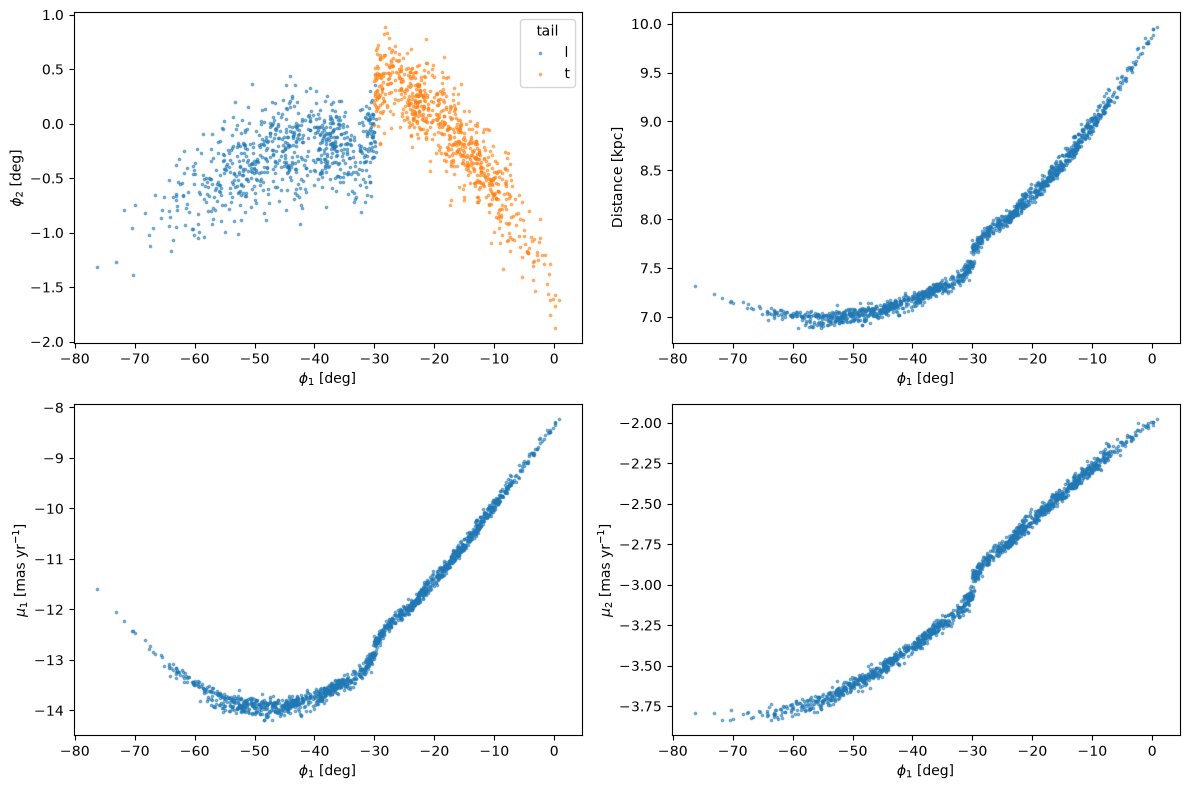

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
phi1 = stream_test_gd1["phi1_deg"]
lead_trail = stream_test_gd1["lead_trail"]

for label in np.unique(lead_trail):
    mask = lead_trail == label
    axes[0, 0].scatter(phi1[mask], stream_test_gd1["phi2_deg"][mask], s=3, alpha=0.5, label=str(label))
axes[0, 0].set(xlabel=r"$\phi_1$ [deg]", ylabel=r"$\phi_2$ [deg]")
axes[0, 0].legend(title="tail")

axes[0, 1].scatter(phi1, stream_test_gd1["distance_kpc"], s=3, alpha=0.5)
axes[0, 1].set(xlabel=r"$\phi_1$ [deg]", ylabel="Distance [kpc]")

axes[1, 0].scatter(phi1, stream_test_gd1["pm1_masyr"], s=3, alpha=0.5)
axes[1, 0].set(xlabel=r"$\phi_1$ [deg]", ylabel=r"$\mu_1$ [mas yr$^{-1}$]")

axes[1, 1].scatter(phi1, stream_test_gd1["pm2_masyr"], s=3, alpha=0.5)
axes[1, 1].set(xlabel=r"$\phi_1$ [deg]", ylabel=r"$\mu_2$ [mas yr$^{-1}$]")

plt.tight_layout()
plt.show()

# 8. Fiducial \(S_0\)

Generate the production control stream with the improved Chen+24 release model and a finite progenitor potential. No parameters are optimized against the observed profiles.

In [10]:
spray_s0, prog_s0, npr_s0 = generate_mock_stream(
    n_particles=N_PARTICLES,
    T_strip=T_STRIP,
    dt=DT,
    release_every=1,
    seed=RNG_SEED,
)
s0_gd1 = mockstream_to_gd1(spray_s0)

print("Fiducial S0 particle count:", spray_s0.shape[0])
print("Particles per tail per release:", npr_s0)
print(
    f"phi1 range = {np.nanmin(s0_gd1['phi1_deg']):.2f} "
    f"to {np.nanmax(s0_gd1['phi1_deg']):.2f} deg"
)

Fiducial S0 particle count: 192064
Particles per tail per release: 32
phi1 range = -82.86 to 9.19 deg


# 9. Stream diagnostics

For science analysis, summarize the particle distribution in \(\phi_1\) bins using medians and robust MAD-based widths. The same binning will be applied to every later perturbation hypothesis.

In [11]:
def robust_stream_profiles(stream, phi1_edges):
    phi1 = np.asarray(stream["phi1_deg"])
    fields = {"phi2":stream["phi2_deg"], "distance":stream["distance_kpc"], "pm1":stream["pm1_masyr"], "pm2":stream["pm2_masyr"], "rv":stream["rv_kms"]}
    centers = 0.5*(phi1_edges[:-1]+phi1_edges[1:])
    rows=[]
    for lo,hi,center in zip(phi1_edges[:-1],phi1_edges[1:],centers):
        mask=(phi1>=lo)&(phi1<hi)
        row={"phi1":center,"N":int(mask.sum())}
        for name,values in fields.items():
            x=np.asarray(values)[mask]; x=x[np.isfinite(x)]
            if len(x)==0: row[f"{name}_med"]=np.nan; row[f"{name}_mad"]=np.nan
            else:
                med=np.median(x); row[f"{name}_med"]=med; row[f"{name}_mad"]=1.4826*np.median(np.abs(x-med))
        rows.append(row)
    return pd.DataFrame(rows)

phi1_edges=np.arange(-90.0,11.0,2.0)
s0_profiles=robust_stream_profiles(s0_gd1,phi1_edges)
s0_profiles.head()

,phi1,N,phi2_med,phi2_mad,distance_med,distance_mad,pm1_med,pm1_mad,pm2_med,pm2_mad,rv_med,rv_mad
0,-89.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-87.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-85.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-83.0,1,-2.474488,0.0,7.56271,0.0,-10.513974,0.0,-3.538289,0.0,249.275039,0.0
4,-81.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 10. Resolution convergence

Compare $N=10^3$, $10^4$, and $5\times10^4$.

Convergence concerns the median tracks and widths, not individual particles.

In [12]:
# Particle-number convergence.
#
# Keep the physical release cadence fixed at 0.5 Myr for every run.
# This isolates Monte-Carlo / particle-resolution effects from changes in
# the stripping history. Because Gala releases an integer number of
# particles per tail at each release time, the realized counts are close
# to (rather than exactly equal to) the requested targets.

convergence_runs = {}

for target_n in [2_000, 10_000, 50_000]:
    stream_n, _, npr_n = generate_mock_stream(
        n_particles=target_n,
        T_strip=T_STRIP,
        dt=DT,
        release_every=1,
        seed=RNG_SEED,
    )

    realized_n = stream_n.shape[0]
    convergence_runs[realized_n] = mockstream_to_gd1(stream_n)

    print(
        f"target N={target_n:,} -> realized N={realized_n:,}; "
        f"particles/tail/release={npr_n}"
    )

# Compare binned median tracks and robust widths against the highest-
# resolution realization. The physics, seed, stripping history, timestep,
# and release cadence are otherwise identical.
phi1_edges = np.arange(-90.0, 11.0, 2.0)
conv_profiles = {
    n: robust_stream_profiles(data, phi1_edges)
    for n, data in convergence_runs.items()
}

ref_n = max(conv_profiles)
ref = conv_profiles[ref_n]

print(f"\nReference resolution: N={ref_n:,}")

for n in sorted(conv_profiles):
    if n == ref_n:
        continue

    print(f"\nN={n:,} vs N={ref_n:,}")

    for field in [
        "phi2_med", "distance_med", "pm1_med", "pm2_med", "rv_med",
        "phi2_mad", "distance_mad", "pm1_mad", "pm2_mad", "rv_mad",
    ]:
        a = conv_profiles[n][field].to_numpy()
        b = ref[field].to_numpy()
        mask = np.isfinite(a) & np.isfinite(b)

        if np.any(mask):
            rms = np.sqrt(np.mean((a[mask] - b[mask])**2))
            print(f"  {field:14s} RMS = {rms:.5g}")


target N=2,000 -> realized N=6,002; particles/tail/release=1
target N=10,000 -> realized N=12,004; particles/tail/release=2
target N=50,000 -> realized N=48,016; particles/tail/release=8

Reference resolution: N=48,016

N=6,002 vs N=48,016
  phi2_med       RMS = 0.036215
  distance_med   RMS = 0.0096118
  pm1_med        RMS = 0.019396
  pm2_med        RMS = 0.0049365
  rv_med         RMS = 0.73882
  phi2_mad       RMS = 0.044126
  distance_mad   RMS = 0.013222
  pm1_mad        RMS = 0.018232
  pm2_mad        RMS = 0.0054282
  rv_mad         RMS = 0.8466

N=12,004 vs N=48,016
  phi2_med       RMS = 0.040268
  distance_med   RMS = 0.0095317
  pm1_med        RMS = 0.016315
  pm2_med        RMS = 0.0037775
  rv_med         RMS = 0.67734
  phi2_mad       RMS = 0.024635
  distance_mad   RMS = 0.005688
  pm1_mad        RMS = 0.014833
  pm2_mad        RMS = 0.0036048
  rv_mad         RMS = 0.43951


## 10.1 Numerical timestep convergence

Particle-number convergence is not enough. We also test whether the phase-space tracks are stable when the integration timestep is halved. The physical stream model, progenitor mass, potential, seed, and stripping duration remain fixed.

In [13]:
stream_dt025, _, npr_dt025 = generate_mock_stream(
    n_particles=10_000,
    T_strip=T_STRIP,
    dt=0.25 * u.Myr,
    release_every=2,  # preserves the same 0.5 Myr physical release cadence
    seed=RNG_SEED,
)
stream_dt025_gd1 = mockstream_to_gd1(stream_dt025)

profiles_dt05 = robust_stream_profiles(s0_gd1, phi1_edges)
profiles_dt025 = robust_stream_profiles(stream_dt025_gd1, phi1_edges)

print("dt=0.5 Myr particles :", len(spray_s0.release_time))
print("dt=0.25 Myr particles:", len(stream_dt025.release_time))
print("dt=0.25 particles/release/tail:", npr_dt025)

print("\nTimestep convergence: dt=0.25 vs dt=0.5 Myr")
for field in [
    "phi2_med", "distance_med", "pm1_med", "pm2_med", "rv_med",
    "phi2_mad", "distance_mad", "pm1_mad", "pm2_mad", "rv_mad",
]:
    a = profiles_dt05[field].to_numpy()
    b = profiles_dt025[field].to_numpy()
    mask = np.isfinite(a) & np.isfinite(b)

    if np.any(mask):
        rms = np.sqrt(np.mean((a[mask] - b[mask])**2))
        print(f"  {field:14s} RMS = {rms:.5g}")


dt=0.5 Myr particles : 192064
dt=0.25 Myr particles: 12004
dt=0.25 particles/release/tail: 2

Timestep convergence: dt=0.25 vs dt=0.5 Myr
  phi2_med       RMS = 0.041575
  distance_med   RMS = 0.010342
  pm1_med        RMS = 0.017115
  pm2_med        RMS = 0.004115
  rv_med         RMS = 0.71417
  phi2_mad       RMS = 0.021195
  distance_mad   RMS = 0.0053246
  pm1_mad        RMS = 0.011159
  pm2_mad        RMS = 0.0033724
  rv_mad         RMS = 0.48878


## 10.2 Stream-coverage gate

Before comparing $S_0$ to GD-1, verify that the generated stream actually
covers the principal observational interval

$$
-60^\circ \leq \phi_1 \leq 0^\circ.
$$

Coverage is a model diagnostic, not something to enforce by truncating the
data or tuning the comparison region.

The fiducial $T_{\rm strip}$ is accepted only if the resulting stream has
substantial particle coverage across the intended interval.

In [14]:
phi1_s0 = np.asarray(s0_gd1["phi1_deg"])
coverage_mask = np.isfinite(phi1_s0)

phi1_min = np.nanmin(phi1_s0[coverage_mask])
phi1_max = np.nanmax(phi1_s0[coverage_mask])

principal_mask = (
    coverage_mask
    & (phi1_s0 >= -60.0)
    & (phi1_s0 <= 0.0)
)

principal_count = int(np.count_nonzero(principal_mask))

print(f"S0 phi1 range: {phi1_min:.2f} to {phi1_max:.2f} deg")
print(f"Particles in -60 <= phi1 <= 0 deg: {principal_count:,}")

if principal_count < 500:
    raise RuntimeError(
        "S0 does not provide enough coverage of the principal GD-1 "
        "comparison region. Increase T_strip only after checking the "
        "stream morphology and convergence diagnostics."
    )

print("Longitudinal coverage gate: PASS")


S0 phi1 range: -82.86 to 9.19 deg
Particles in -60 <= phi1 <= 0 deg: 185,812
Longitudinal coverage gate: PASS


# 11. Validation against observed GD-1

First compare broad morphology in
$\phi_1,\phi_2,d,\mu_1,\mu_2,v_r$.

The main validation region is

$$
-60^\circ \leq \phi_1 \leq 0^\circ,
$$

where the observational baseline is best constrained.

The goal is a **dynamically plausible control model**, not a perfect empirical fit.
We explicitly report model/data mismatch rather than optimizing $S_0$ until it
agrees with the data.

The observational distance comparison uses the literature distance track
inherited from Notebook 01, not naive inverse Gaia parallax.

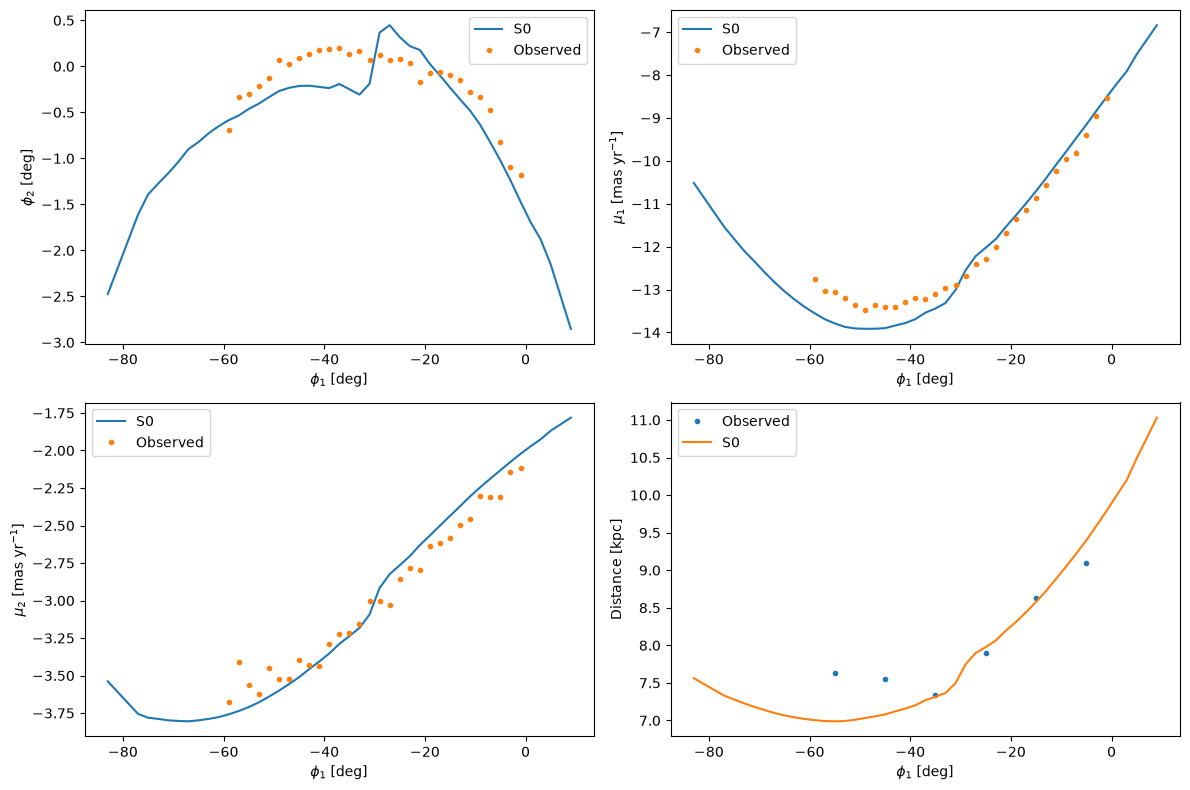

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

obs = gd1_profiles

# Restrict the visual comparison to the principal GD-1 region.
model_mask = (
    np.isfinite(s0_profiles["phi2_med"])
    | np.isfinite(s0_profiles["pm1_med"])
    | np.isfinite(s0_profiles["pm2_med"])
    | np.isfinite(s0_profiles["distance_med"])
)

obs_mask = (
    (obs["phi1"] >= -60.0)
    & (obs["phi1"] <= 0.0)
)

# ------------------------------------------------------------
# Track: phi2
# ------------------------------------------------------------

axes[0, 0].plot(
    s0_profiles.loc[model_mask, "phi1"],
    s0_profiles.loc[model_mask, "phi2_med"],
    label="S0",
)

axes[0, 0].plot(
    obs.loc[obs_mask, "phi1"],
    obs.loc[obs_mask, "phi2_med"],
    "o",
    ms=3,
    label="Observed",
)

axes[0, 0].set_xlabel(r"$\phi_1$ [deg]")
axes[0, 0].set_ylabel(r"$\phi_2$ [deg]")
axes[0, 0].legend()

# ------------------------------------------------------------
# Proper motion: pm1
# ------------------------------------------------------------

axes[0, 1].plot(
    s0_profiles.loc[model_mask, "phi1"],
    s0_profiles.loc[model_mask, "pm1_med"],
    label="S0",
)

axes[0, 1].plot(
    obs.loc[obs_mask, "phi1"],
    obs.loc[obs_mask, "pm1_med"],
    "o",
    ms=3,
    label="Observed",
)

axes[0, 1].set_xlabel(r"$\phi_1$ [deg]")
axes[0, 1].set_ylabel(r"$\mu_1$ [mas yr$^{-1}$]")
axes[0, 1].legend()

# ------------------------------------------------------------
# Proper motion: pm2
# ------------------------------------------------------------

axes[1, 0].plot(
    s0_profiles.loc[model_mask, "phi1"],
    s0_profiles.loc[model_mask, "pm2_med"],
    label="S0",
)

axes[1, 0].plot(
    obs.loc[obs_mask, "phi1"],
    obs.loc[obs_mask, "pm2_med"],
    "o",
    ms=3,
    label="Observed",
)

axes[1, 0].set_xlabel(r"$\phi_1$ [deg]")
axes[1, 0].set_ylabel(r"$\mu_2$ [mas yr$^{-1}$]")
axes[1, 0].legend()

# ------------------------------------------------------------
# Distance comparison
# ------------------------------------------------------------

distance_obs = gd1_distance[
    (gd1_distance["phi1_deg"] >= -60.0)
    & (gd1_distance["phi1_deg"] <= 0.0)
]

# Observed distance track
axes[1, 1].plot(
    distance_obs["phi1_deg"],
    distance_obs["distance_kpc"],
    "o",
    ms=3,
    label="Observed",
)

# S0 distance profile
axes[1, 1].plot(
    s0_profiles.loc[model_mask, "phi1"],
    s0_profiles.loc[model_mask, "distance_med"],
    label="S0",
)

axes[1, 1].set_xlabel(r"$\phi_1$ [deg]")
axes[1, 1].set_ylabel("Distance [kpc]")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 11.1 Export the canonical \(S_0\)

The final-state particle realization is written to `data/derived/s0/` so the later perturbation notebooks can use exactly the same unperturbed control stream rather than regenerating it with a different random realization.


In [16]:
# ============================================================
# Export canonical S0
# ============================================================

S0_DIR = PROJECT_ROOT / "data" / "derived" / "s0"
S0_DIR.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    S0_DIR / "S0_particles.npz",
    pos_kpc=spray_s0.pos.xyz.to_value(u.kpc),
    vel_kpc_myr=spray_s0.vel.d_xyz.to_value(u.kpc/u.Myr),
    release_time_myr=spray_s0.release_time.to_value(u.Myr),
    lead_trail=np.asarray(spray_s0.lead_trail),
    phi1_deg=s0_gd1["phi1_deg"],
    phi2_deg=s0_gd1["phi2_deg"],
    distance_kpc=s0_gd1["distance_kpc"],
    pm1_masyr=s0_gd1["pm1_masyr"],
    pm2_masyr=s0_gd1["pm2_masyr"],
    rv_kms=s0_gd1["rv_kms"],
)

metadata = {
    "model": "unperturbed_chen2024_mockstream_S0",
    "N_particles": int(spray_s0.shape[0]),
    "M_prog_Msun": float(M_PROG.to_value(u.Msun)),
    "r_half_pc": float(R_HALF.to_value(u.pc)),
    "plummer_b_pc": float(PLUMMER_B.to_value(u.pc)),
    "T_strip_Myr": float(T_STRIP.to_value(u.Myr)),
    "dt_Myr": float(DT.to_value(u.Myr)),
    "release_cadence_Myr": float(RELEASE_CADENCE.to_value(u.Myr)),
    "random_seed": int(RNG_SEED),
    "potential": "gala.MilkyWayPotential(version='v2')",
    "stream_df": "ChenStreamDF (Chen et al. 2024)",
    "progenitor_potential": "PlummerPotential",
    "gd1_frame": "GD1Koposov10",
    "anchor_phi1_deg": float(anchor["phi1_deg"]),
}

with open(S0_DIR / "S0_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Canonical S0 exported to:", S0_DIR.resolve())
print("Particle file:", S0_DIR / "S0_particles.npz")
print("Metadata file:", S0_DIR / "S0_metadata.json")


Canonical S0 exported to: /home/darxsouls/research/stellar_streams/data/derived/s0
Particle file: /home/darxsouls/research/stellar_streams/data/derived/s0/S0_particles.npz
Metadata file: /home/darxsouls/research/stellar_streams/data/derived/s0/S0_metadata.json


# 12. Final $S_0$ contract

The canonical unperturbed control stream $S_0$ is a reproducible final-state
particle realization with:

- Galactocentric 6-D phase-space coordinates;
- GD-1 $(\phi_1,\phi_2,d,\mu_1,\mu_2,v_r)$;
- release time;
- leading/trailing label;
- finite Plummer progenitor potential;
- fixed progenitor mass/size assumptions;
- fixed Galactic potential;
- reproducible random seed.

Before freezing $S_0$, the notebook requires:

1. particle-number convergence at fixed physical release cadence;
2. timestep convergence;
3. adequate longitudinal coverage of the principal GD-1 region;
4. broad observational validation without fitting the model to the data.

The exported `S0_particles.npz` becomes the common starting point for the later
DM, GMC, GC, and Galactic-potential perturbation experiments.

**Important:** the smooth progenitor orbit is only the reference trajectory used
to construct the stream. The scientific comparison in later notebooks is
performed on the extended particle distribution, not on a single best-fit orbit.

### Frozen fiducial configuration

- **MW potential:** Gala `MilkyWayPotential(v2)`
- **GD-1 frame:** `GD1Koposov10`
- **Stream model:** `ChenStreamDF` + `MockStreamGenerator`
- **Progenitor:** $M_{\rm prog}=2\times10^4\,M_\odot$
- **Half-mass radius:** $r_h=20$ pc
- **Plummer scale:** derived consistently from $r_h$
- **Stripping duration:** **1.5 Gyr**
- **Integration timestep:** **0.5 Myr**
- **Physical release cadence:** **0.5 Myr**
- **Fiducial requested particles:** $1.92\times10^5$
- **Realized particles:** `192,064`
- **Particles per tail per release:** `32`
- **Random seed:** `314159`